# Q1
>1. Linear regression:
Parametric model. (It assumes a linear relationship and learns fixed weights).
View source details. Opens side panel.
>2. k nearest neighbour: 
Non-parametric model. (It assumes no specific mathematical form and stores all training data for prediction).
>3. Logistic regression: 
Parametric model. (It assumes a specific logistic curve and learns fixed weights).
>4. Neural network: 
Parametric model. (A standard artificial neural network has a fixed, predefined architecture and learns a fixed set of weight parameters).


# Q2: Perceptron Prediction

>## 1. Make Predictions

* **For sample $(x_0, x_1) = (3, 0)$:**
   Calculation: $1 \times 3 + (-2) \times 0 + (-1) = 3 - 0 - 1 = 2$
   Result: Since $2 > 0$, the prediction is **$\hat{y} = sign(2) = 1$**.

* **For sample $(x_0, x_1) = (1, 1)$:**
   Calculation: $1 \times 1 + (-2) \times 1 + (-1) = 1 - 2 - 1 = -2$
   Result: Since $-2 \le 0$, the prediction is **$\hat{y} = sign(-2) = -1$**.

>## 2. Decision Boundary Plot
The decision boundary occurs where the input to the sign function is zero:
$1x_{0} - 2x_{1} - 1 = 0 \Rightarrow 2x_{1} = x_{0} - 1 \Rightarrow x_{1} = 0.5x_{0} - 0.5$.
*(See the code cell below to generate the plot)*

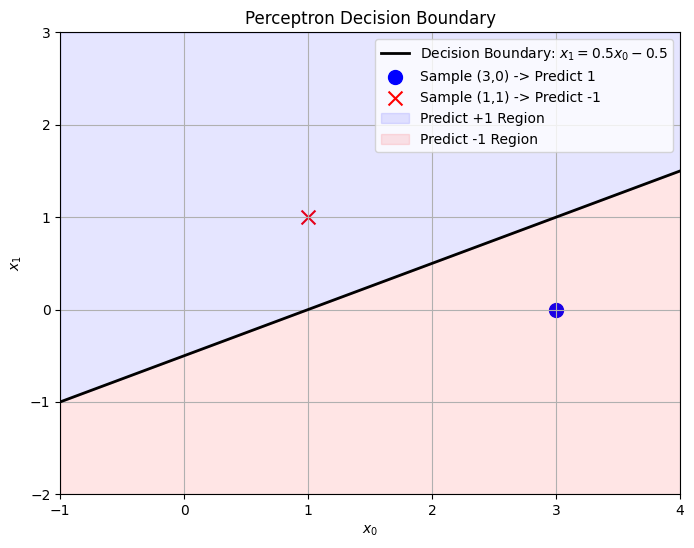

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x0 = np.linspace(-1, 4, 100)
x1 = 0.5 * x0 - 0.5

plt.figure(figsize=(8, 6))
plt.plot(x0, x1, label='Decision Boundary: $x_1 = 0.5x_0 - 0.5$', color='black', linewidth=2)
plt.scatter(3, 0, color='blue', label='Sample (3,0) -> Predict 1', marker='o', s=100)
plt.scatter(1, 1, color='red', label='Sample (1,1) -> Predict -1', marker='x', s=100)
plt.fill_between(x0, x1, 3, color='blue', alpha=0.1, label='Predict +1 Region')
plt.fill_between(x0, x1, -2, color='red', alpha=0.1, label='Predict -1 Region')
plt.xlim(-1, 4)
plt.ylim(-2, 3)
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.title('Perceptron Decision Boundary')
plt.grid(True)
plt.legend()
plt.show()

>## 3. Parameter Update

  * **Yes.** For the sample $(3,0)$, the correct label is $y=-1$, but our current model predicts $\hat{y}=1$ (as calculated in Part 1). Since there is a misclassification, the parameters must be updated.
  * Using the standard perceptron learning rule for labels $y \in \{1, -1\}$: $w_i \leftarrow w_i + \eta y x_i$
  * Given learning rate $\eta = 1$.
  * Update $w_0$: $w_0 = 1 + (1) \times (-1) \times 3 = 1 - 3 = -2$
  * Update $w_1$: $w_1 = -2 + (1) \times (-1) \times 0 = -2 - 0 = -2$
  * The updated parameters $(w_0, w_1)$ should be **$(-2, -2)$**.

# Q3: Classification Loss Function

The binary cross entropy loss function is: 
$L(\hat{y},y) = -y\log(\hat{y}) - (1-y)\log(1-\hat{y})$

>## 1. Domains
* Domain of true label $y$: $\{0, 1\}$. In binary classification, the actual label must be exactly one of the two discrete classes.
* Domain of prediction $\hat{y}$: $(0, 1)$. The predicted value represents a probability, so it falls strictly between 0 and 1. Absolute 0 and 1 are mathematically excluded to prevent $\log(0)$ which is undefined.

>## 2. Plotting $L(\hat{y})$
*(See the code cell below to generate the plot)*

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
C:\Users\28695\AppData\Local\Temp\ipykernel_27804\4148896131.py:10: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Predicted Probability $\hat{y}$')
C:\Users\28695\AppData\Local\Temp\ipykernel_27804\4148896131.py:11: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Loss $L(\hat{y}, y)$')


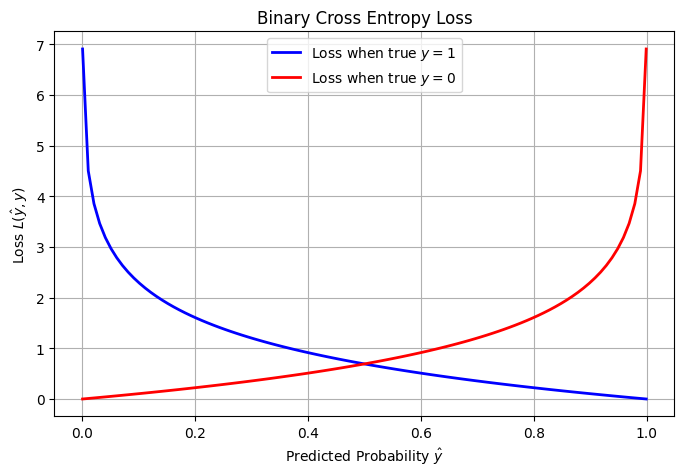

In [3]:
import numpy as np
import matplotlib.pyplot as plt

y_hat = np.linspace(0.001, 0.999, 100) 
loss_y1 = -np.log(y_hat)       
loss_y0 = -np.log(1 - y_hat)   
plt.figure(figsize=(8, 5))
plt.plot(y_hat, loss_y1, label='Loss when true $y = 1$', color='blue', linewidth=2)
plt.plot(y_hat, loss_y0, label='Loss when true $y = 0$', color='red', linewidth=2)
plt.xlabel('Predicted Probability $\hat{y}$')
plt.ylabel('Loss $L(\hat{y}, y)$')
plt.title('Binary Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

>## 3. Why minimizing drives $\hat{y}$ towards $y$
* When $y = 1$: The formula simplifies to $L = -\log(\hat{y})$. To minimize this loss (push it closer to 0), the model must maximize $\hat{y}$. This drives the predicted probability $\hat{y}$ closer to 1 (which is the true value $y$).
* When $y = 0$: The formula simplifies to $L = -\log(1-\hat{y})$. To minimize this, $1-\hat{y}$ must be maximized, which means $\hat{y}$ itself must be minimized. This pushes $\hat{y}$ towards 0 (which is the true value $y$).

>## 4. Sharp penalization of incorrect predictions
* This happens due to the asymptotic nature of the logarithmic function. 
* As a prediction approaches absolute confidence but is completely wrong (e.g., predicting $\hat{y} \to 0$ when the true label is $y=1$), the logarithm approaches negative infinity ($-\infty$). 
* Combined with the negative sign at the front of the formula, the loss spikes exponentially towards positive infinity. This creates a massive error signal, heavily penalizing confident but incorrect predictions to force the model to correct itself quickly.

# Q4: Classify Different Types of Iris
This notebook implements the machine learning workflow to predict whether a given iris flower belongs to the Versicolour type.

In [5]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


X, y = load_iris(return_X_y=True)
y = (y == 1).astype(int)
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset divided successfully:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

#kNN model
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

#Predict and evaluate
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"k-NN (k=3) Accuracy: {acc_knn:.4f}")

#Initialize and train the Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

#Predict and evaluate
y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

#Performance Comparison
print("\n--- Performance Comparison ---")
if acc_knn > acc_lr:
    print("k-NN model performed better in terms of accuracy.")
elif acc_knn < acc_lr:
    print("Logistic Regression model performed better in terms of accuracy.")
else:
    print("Both models achieved the exact same accuracy on the test set.")

#Evaluate the precision, recall, and the F_1 score for both models.
def evaluate_metrics(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {model_name} Metrics ---")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")

evaluate_metrics(y_test, y_pred_knn, "k-NN (k=3)")
evaluate_metrics(y_test, y_pred_lr, "Logistic Regression")


X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

best_k = 1
best_val_acc = 0

print("Tuning hyperparameter 'k' on the validation set...")
for k in range(1, 21):
    #Train on the smaller training subset
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_sub, y_train_sub)
    
    #Evaluate on the validation set
    val_acc = accuracy_score(y_val, knn_temp.predict(X_val))
    
    #Keep track of the best performance
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k

print(f"-> The optimal 'k' found is: {best_k} (Validation Accuracy: {best_val_acc:.4f})\n")

#retrain the optimal model on the FULL training set (80%) and evaluate it on the UNSEEN test set (20%)
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(X_train, y_train)

final_test_acc = accuracy_score(y_test, best_knn_model.predict(X_test))
print(f"Test Accuracy of the optimally tuned k-NN model (k={best_k}): {final_test_acc:.4f}")



Dataset divided successfully:
Training set size: 120 samples
Test set size: 30 samples
k-NN (k=3) Accuracy: 1.0000
Logistic Regression Accuracy: 0.8000

--- Performance Comparison ---
k-NN model performed better in terms of accuracy.
--- k-NN (k=3) Metrics ---
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

--- Logistic Regression Metrics ---
Precision: 0.7143
Recall:    0.5556
F1 Score:  0.6250

Tuning hyperparameter 'k' on the validation set...
-> The optimal 'k' found is: 2 (Validation Accuracy: 0.9333)

Test Accuracy of the optimally tuned k-NN model (k=2): 1.0000
